<a href="https://colab.research.google.com/github/mzrmax/AbadAravenaDS/blob/main/Cap2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

COPIADO DESDE cap2_bas.py

In [ ]:
#### 22/09/26
#### OBJ: ESTANDARIZAR TRABAJOS DE ML EN COLAB

0. CONFIGURACIÓN PREVIA

In [14]:
#### LIBRERÍAS

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split



#### 0.1 CONFIGURACIONES DE PANDAS

## MURESTRA TODAS LAS COLUMNAS
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)

## NO HACE SALTO DE LINEA EN CMD
pd.set_option("display.width", None)

## TAMAÑO MAX COLUMNAS
pd.set_option("display.max_colwidth", 40)



#### 0.2 CARGA DE BASE DE DATOS

# CARGA LA BASE DE DATOS
df = pd.read_csv("housing.csv")

1. VISUALIZACIÓN DE DATOS

In [15]:
#### 1.1 RECONOCIMIENTO

# MUESTRA LOS DATOS
print(df.head())
# MUESTRA LOS DATOS
print(df.info())
# MUESTRA LOS DATOS
print(df.describe())

# CUENTA TODOS LOS DATOS
#print(df.value_counts())

print(df.columns)

# CUENTA DATOS DEL ATRUBITO SOLICITAOD
print(df["ocean_proximity"].value_counts())

   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.23     37.88                41.0        880.0           129.0   
1    -122.22     37.86                21.0       7099.0          1106.0   
2    -122.24     37.85                52.0       1467.0           190.0   
3    -122.25     37.85                52.0       1274.0           235.0   
4    -122.25     37.85                52.0       1627.0           280.0   

   population  households  median_income  median_house_value ocean_proximity  
0       322.0       126.0         8.3252            452600.0        NEAR BAY  
1      2401.0      1138.0         8.3014            358500.0        NEAR BAY  
2       496.0       177.0         7.2574            352100.0        NEAR BAY  
3       558.0       219.0         5.6431            341300.0        NEAR BAY  
4       565.0       259.0         3.8462            342200.0        NEAR BAY  
<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data colum

Text(0.5, 1.0, 'VALORES')

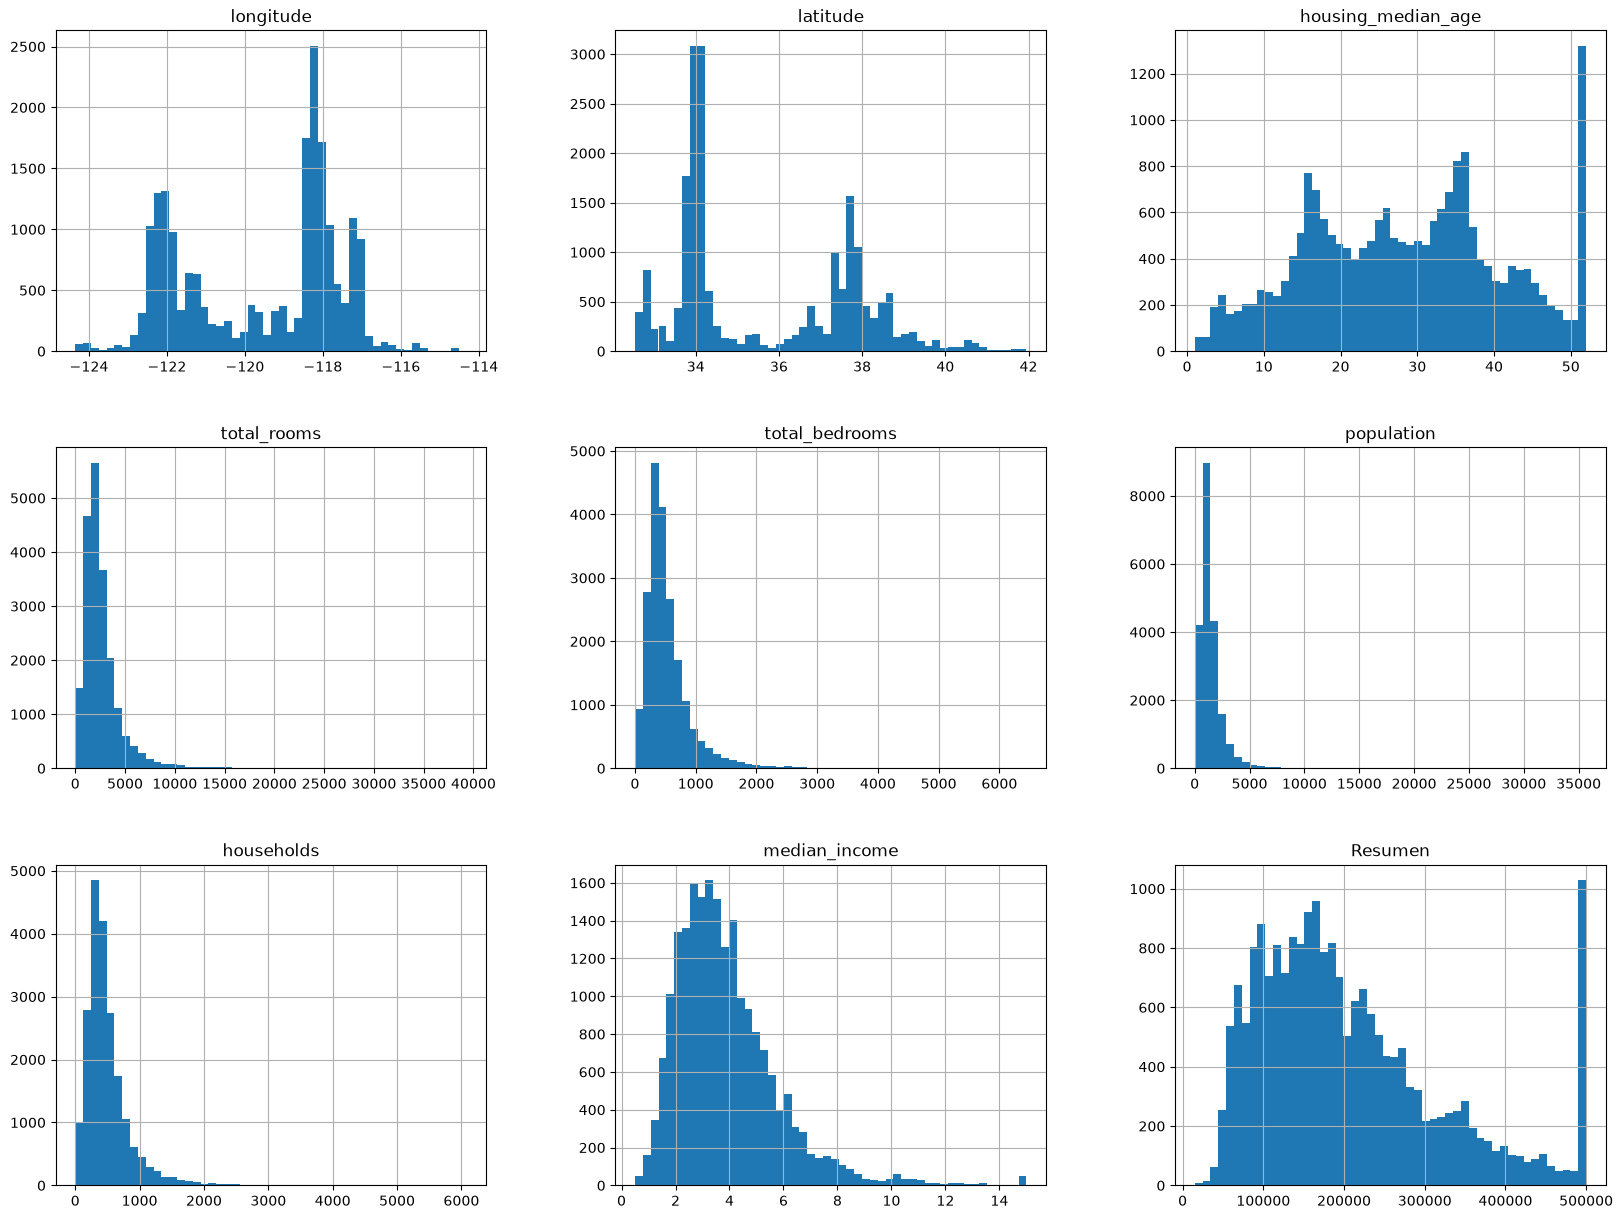

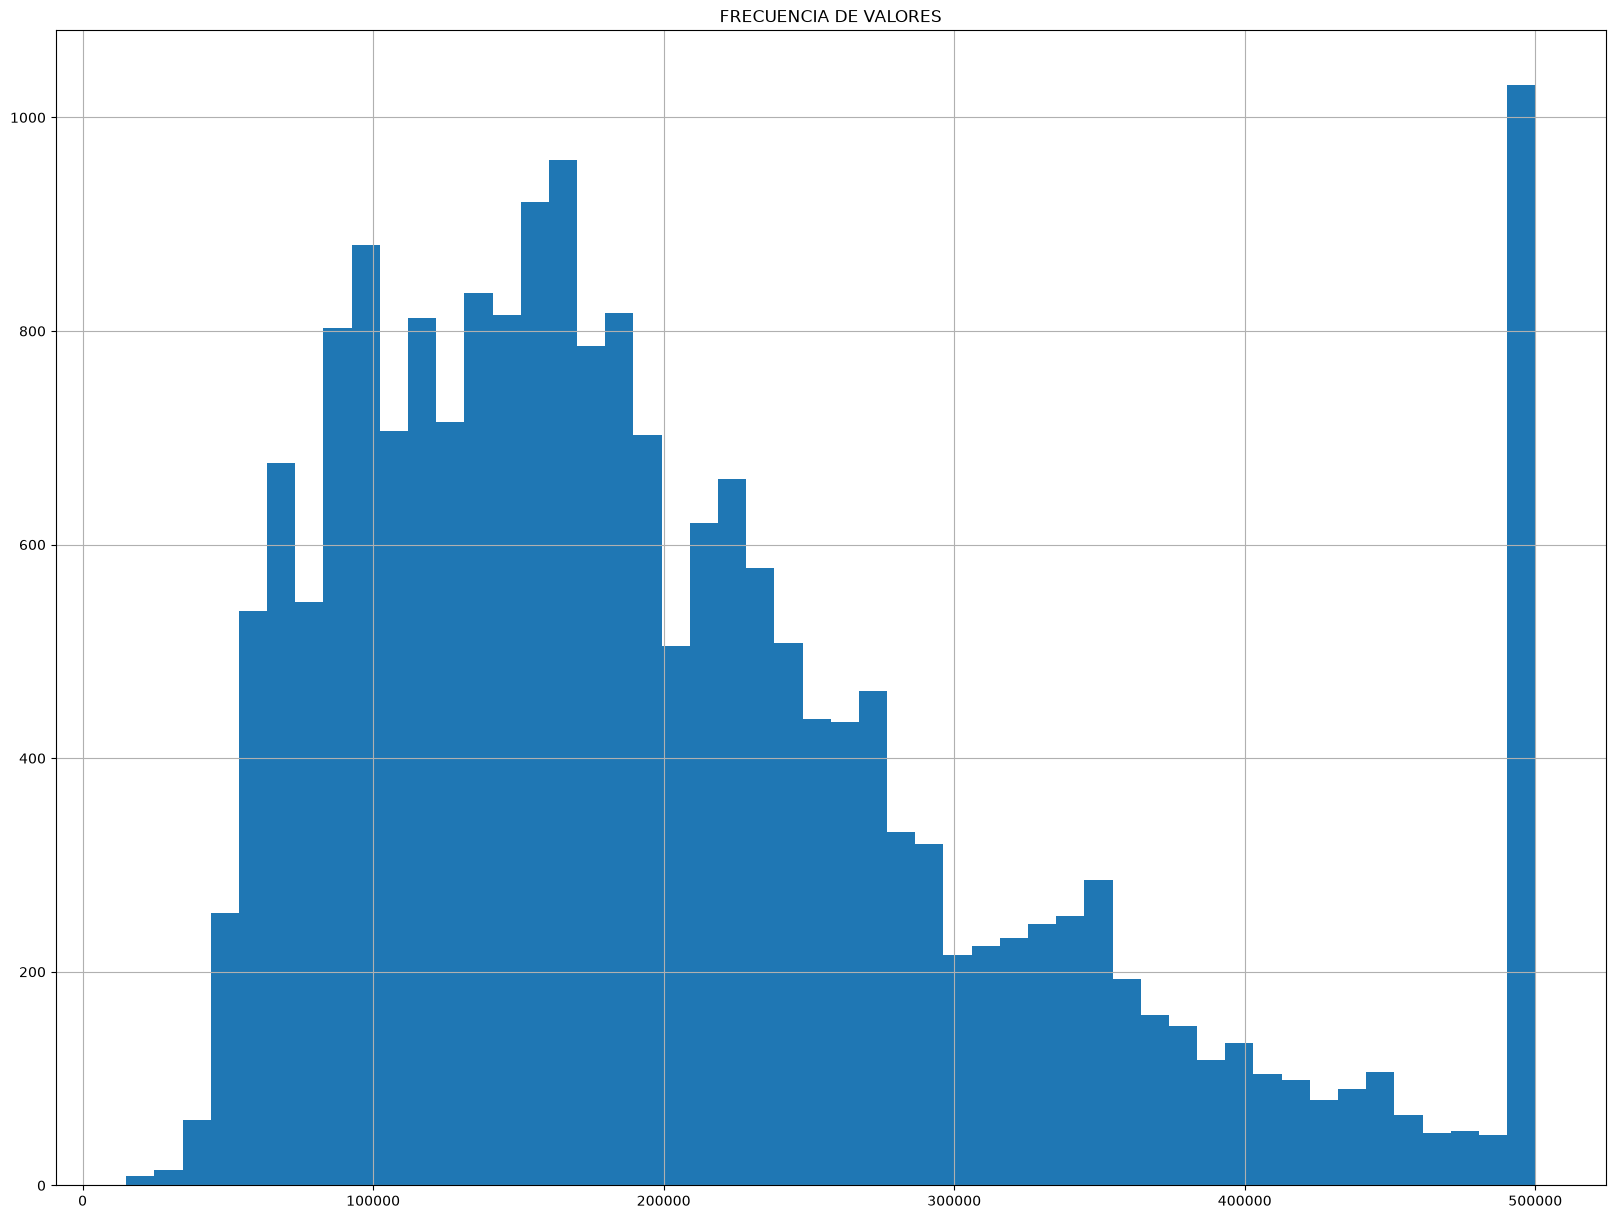

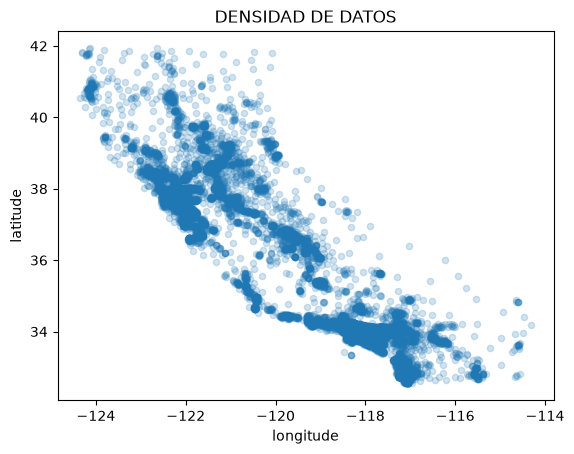

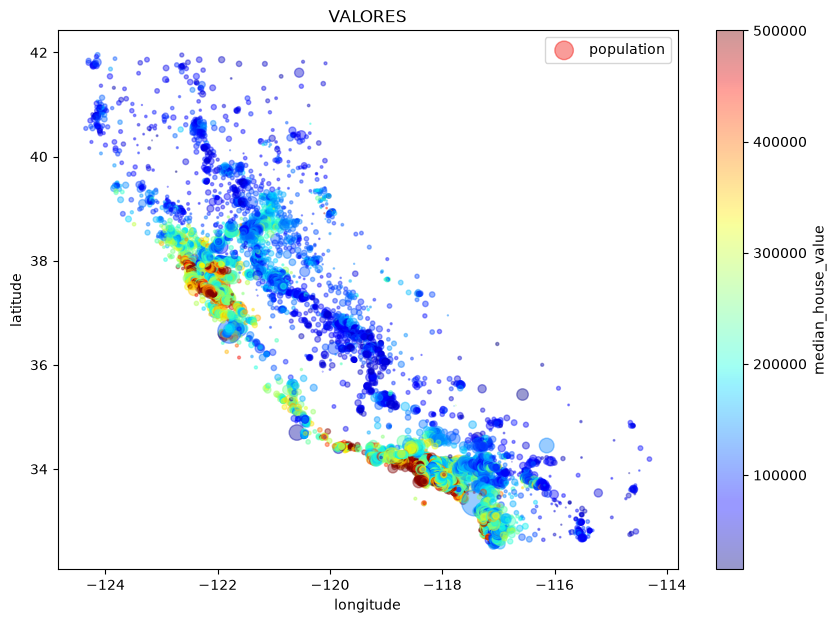

In [5]:

#### 1.2 GRÁFICOS

# HISTOGRAMAS
#plt.figure()
df.hist(bins=50, figsize=(20,15))
plt.title("Resumen")


# SOLO UN FEATURE
plt.figure()
df["median_house_value"].hist(bins=50, figsize=(20,15))
plt.title("FRECUENCIA DE VALORES")

# DENSIDAD DE LOS DATOS
#plt.figure()
df.plot(kind="scatter", x="longitude", y="latitude", alpha=0.2)
plt.title("DENSIDAD DE DATOS")

# COLORMAT
#plt.figure()
df.plot(    kind    ="scatter",
            x       ="longitude",
            y       ="latitude",
            alpha   =0.4,
            s       =df["population"]/100,
            label   ="population",
            figsize =(10,7),
            c       ="median_house_value",
            cmap=plt.get_cmap("jet"),
            colorbar=True,)
plt.legend()
plt.title("VALORES")

2. CORRELACIONES

['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'median_house_value']
==== CORRELACIONES ====

median_house_value    1.000000
median_income         0.688075
total_rooms           0.134153
housing_median_age    0.105623
households            0.065843
total_bedrooms        0.049686
population           -0.024650
longitude            -0.045967
latitude             -0.144160
Name: median_house_value, dtype: float64


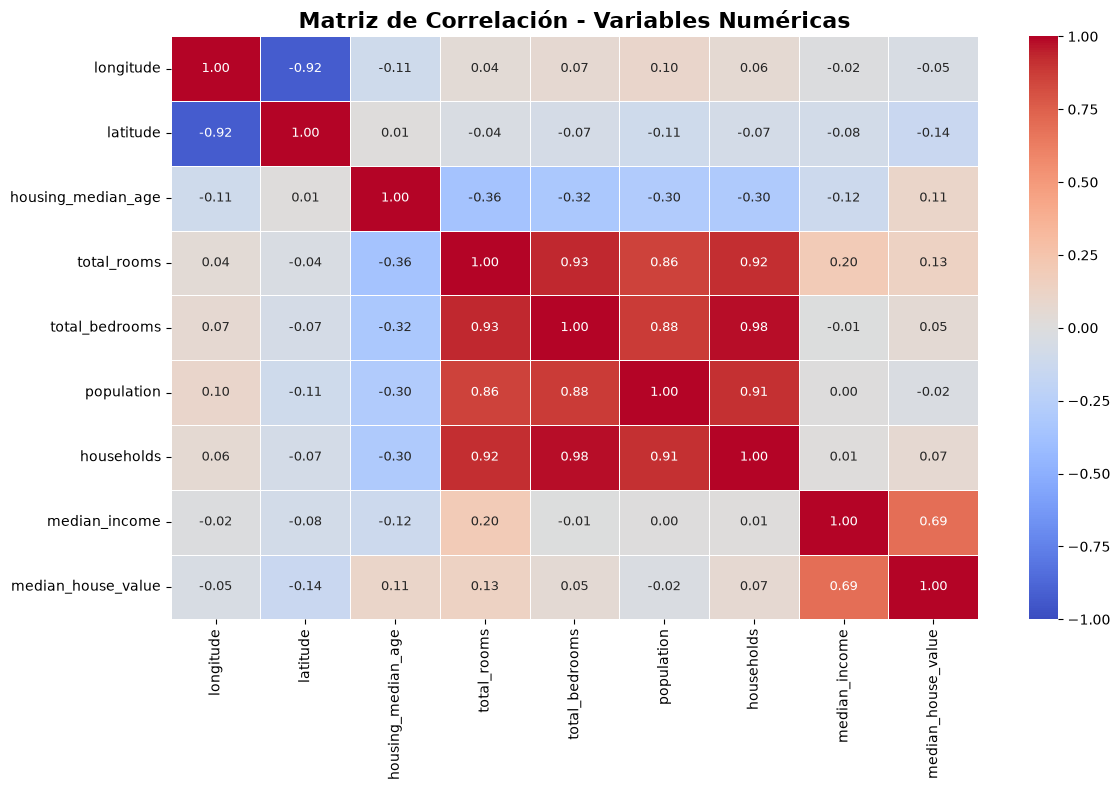

In [17]:
#### 2.1 GUARDA DATOS NUMÉRICOS
df_num = df.select_dtypes(include='number').columns.tolist()

print(df_num)

print("==== CORRELACIONES ====\n")

# SE SELECCIONAN VARIABLES ÚNICAMENTE NUMÉRICAS
df_numerical = df.select_dtypes(include=['int64', 'float64']).copy()
df_numerical = df_numerical.drop(columns=['id_estudiante'], errors='ignore')

# SE MUESTRAN CORRELACIONES CON NOTA FINAL
corr_final = df_numerical.corr()['median_house_value'].sort_values(ascending=False)
print(corr_final)


# SE PREPARA LA MATRIZ DE CORRELACIÓN
plt.figure(figsize=(12, 8))
sns.heatmap(    df_numerical.corr(),
                annot=True,
                fmt='.2f',
                cmap='coolwarm',
                vmin=-1,
                vmax=1,
                linewidths=0.5,
                linecolor='white',
                annot_kws={'size': 9})

plt.title('Matriz de Correlación - Variables Numéricas', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


3. TRATAMIENTO DE DATOS

In [ ]:
#### 3.1 TRATAMIENTO DE DATOS



#### 3.2 ESTRATIFICACIÓN

df["income_cat"] = pd.cut(
    df["median_income"],
    bins=[0., 1.5, 3.0, 4.5, 6., np.inf],
    labels=[1, 2, 3, 4, 5])

plt.figure()
df["income_cat"].hist()

plt.show()



#### 2.3 SAMPLEO

train_set, test_set = train_test_split(df, test_size=0.2, random_state=42)
